In [18]:
from typing import TypedDict, Literal
from langgraph.graph import StateGraph, START, END

In [26]:
class QuadState(TypedDict):
    a: int
    b: int
    c: int

    equation: str
    D: int
    comment: str
    root1: float
    root2: float

In [27]:
def build_equation(state: QuadState) -> QuadState:
    a = state['a']
    b = state['b']
    c = state['c']

    state['equation'] = f"{a}x^2 + {b}x + {c}"

    return state

In [28]:
def calculate_discriminant(state: QuadState) -> QuadState:
    a = state['a']
    b = state['b']
    c = state['c']

    state['D'] = (b**2) - (4*a*c)

    return state

In [29]:
def distinct_roots(state: QuadState):
    a = state['a']
    b = state['b']
    c = state['c']
    D = state['D']

    root1 = ((-1*b) + (D**0.5))/(2*a)
    root2 = ((-1*b) - (D**0.5))/(2*a)
    comment = "Distinct real roots"

    return {'comment': comment, 'root1': root1, 'root2': root2}

def equal_roots(state: QuadState):
    a = state['a']
    b = state['b']
    c = state['c']
    D = state['D']

    root = (-1*b)/(2*a)

    comment = "Equal real roots"

    return {'comment': comment, 'root1': root, 'root2': root}

def no_real_roots(state: QuadState):
    comment = "No real roots"

    return {'comment': comment}

In [30]:
def check_condition(state: QuadState) -> Literal['distinct_roots', 'equal_roots', 'no_real_roots']:
    D = state['D']

    if D>0:
        return 'distinct_roots'
    elif D<0:
        return 'no_real_roots'
    else:
        return 'equal_roots'

In [31]:
graph = StateGraph(QuadState)

graph.add_node('show_equation', build_equation)
graph.add_node('calculate_discriminant', calculate_discriminant)
graph.add_node('distinct_roots', distinct_roots)
graph.add_node('equal_roots', equal_roots)
graph.add_node('no_real_roots', no_real_roots)

graph.add_edge(START, 'show_equation')
graph.add_edge('show_equation', 'calculate_discriminant')
graph.add_edge('show_equation', 'calculate_discriminant')
graph.add_conditional_edges('calculate_discriminant', check_condition)
graph.add_edge('distinct_roots', END)
graph.add_edge('equal_roots', END)
graph.add_edge('no_real_roots', END)

workflow = graph.compile()

In [34]:
initial_state = {'a': 1, 'b': 3, 'c': 2}
output_state = workflow.invoke(initial_state)

print(output_state)

{'a': 1, 'b': 3, 'c': 2, 'equation': '1x^2 + 3x + 2', 'D': 1, 'comment': 'Distinct real roots', 'root1': -1.0, 'root2': -2.0}


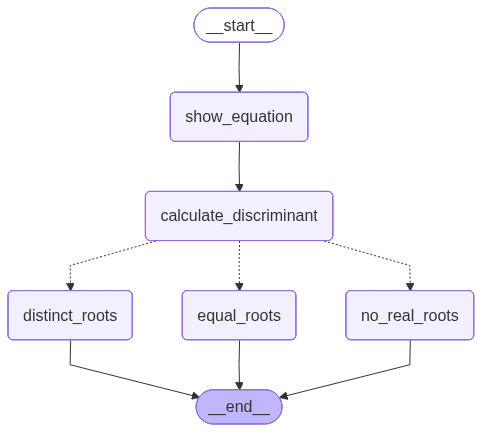

In [35]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())